In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from scipy import stats
from matplotlib.patches import Patch
from scipy.stats import zscore, false_discovery_control

from cat_whim.config import PROCESSED_DATA_DIR, INTERIM_DATA_DIR, REPORTS_DIR

2025-05-07 14:24:47.618 | INFO     | cat_whim.config:<module>:12 - PROJ_ROOT path is: /home/leoner/Projects/cat_whim


In [3]:
sns.set_palette("tab10")

In [4]:
def make_demographics_table(df):
    df_m00 = df[df["session"] == "M00"].copy()
    # Continuous variables
    continuous_vars = ["AGE", "PTEDUCAT", "MMSE", "wmh_vol_log", "RAVLT_forgetting"]
    normality_results = {}
    desc_stats = {}

    for var in continuous_vars:
        # Perform Shapiro-Wilk test for normality
        stat, p_value = stats.shapiro(df_m00[var].dropna())  # Drop NA values for the test
        normality_results[var] = p_value

        # Calculate mean and SD or median and IQR based on normality
        if p_value > 0.05:  # Data is normal
            desc_stats[var] = {
                "Variable": var,
                "Statistic": f"{df_m00[var].mean():.2f} ± {df_m00[var].std():.2f}",
                "Note": "Mean (SD)",
            }
            print(var, "mean (SD)")
        else:  # Data is not normal
            desc_stats[var] = {
                "Variable": var,
                "Statistic": f"{df_m00[var].median():.2f} ({df_m00[var].quantile(0.25):.2f} - {df_m00[var].quantile(0.75):.2f})",
                "Note": "Median (IQR)",
            }

    # Categorical variables
    categorical_vars = ["PTGENDER", "DX", "AMYLOID_STATUS"]
    cat_stats = []

    for var in categorical_vars:
        # Add the variable name as the first row
        cat_stats.append({"Variable": var, "Statistic": "", "Note": "Frequency and Proportion"})

        # Get frequency and proportions
        freq = df_m00[var].value_counts()
        proportions = df_m00[var].value_counts(normalize=True)

        # Add each group as a separate row
        for index in freq.index:
            cat_stats.append(
                {
                    "Variable": f"{var} - {index}",
                    "Statistic": f"{freq[index]} ({proportions[index] * 100:.1f}%)",
                    "Note": "",
                }
            )

    # Combine continuous and categorical tables
    table = pd.DataFrame.from_dict(desc_stats, orient="index")
    cat_table = pd.DataFrame(cat_stats)

    df_fu = df[df['Years_m00'] != 0].copy()
    demo_fu = pd.DataFrame({"Variable": [f"Follow-Up, years (n={df_fu['PTID'].nunique()})"],
                "Statistic": [f"{df_fu['Years_m00'].median():.2f} ({df_fu['Years_m00'].quantile(0.25):.2f} - {df_fu['Years_m00'].quantile(0.75):.2f})"],
                })

    # Combine both tables into one final table
    final_table = pd.concat([table, cat_table, demo_fu], axis=0, ignore_index=True)
    num_subj = df_m00["PTID"].nunique()
    demo_table = final_table[["Variable", "Statistic"]].copy()
    demo_table = demo_table.rename(columns={"Statistic": f"All (n = {num_subj})"})
    return demo_table


def plot_regplot_with_corr(df, x, y, ax=None):
    """
    Plots a regression plot with Seaborn and adds the correlation coefficient
    (Pearson or Spearman) to the title of the plot.

    Parameters:
    - x: array-like or pandas Series
    - y: array-like or pandas Series
    - ax: matplotlib axis object, optional

    Returns:
    - ax: The matplotlib axis with the plot
    """
    # Create a matplotlib axis if not provided
    if ax is None:
        fig, ax = plt.subplots()

    # Test normality of x and y using Shapiro-Wilk test
    _, p_x = stats.shapiro(df[x])
    _, p_y = stats.shapiro(df[y])

    # Choose correlation method: Spearman for non-normal data, Pearson for normal data
    if p_x < 0.05 or p_y < 0.05:
        corr_method = "Spearman"
        corr_coef, p = stats.spearmanr(df[x], df[y])
    else:
        corr_method = "Pearson"
        corr_coef, p = stats.pearsonr(df[x], df[y])

    # Plot regression plot using Seaborn
    sns.regplot(data=df, x=x, y=y, ax=ax, line_kws={"color":"red"}, scatter_kws={"color":"black", "alpha": 0.4, "s":20})

    # Add the correlation coefficient to the title
    ax.set_title(f"{corr_method} r = {corr_coef:.2f}, p = {p:.2f}", fontsize=8)

    return ax

def plot_boxplot_with_comparison(df, ax, x, y, pairs):
    from statannotations.Annotator import Annotator

    # Plot each boxplot and add statistical annotations
    sns.boxplot(data=df, x=x, y=y, ax=ax, palette="tab10", hue=x)
    annotator = Annotator(ax, pairs, data=df, x=x, y=y)
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=2)
    annotator.apply_and_annotate()

def calculate_cross_sectional_associations(df, roi_list, roi_names, dx_var, apoe=False, do_zscore=False):
    
    # Get only the first timepoint
    df_m00 = df[df["session"] == "M00"].copy()
    if do_zscore:
        # Z-score the log of WMH volume
        df_m00["wmh_vol_log"] = zscore(df_m00["wmh_vol_log"])
        # Z-score the RAVLT
        df_m00["RAVLT_forgetting"] = zscore(df_m00["RAVLT_forgetting"])
    
    # Create lists for the beta coefficients for disconnections and wmh...
    list_beta_wmh = []
    list_beta_amy_wmh = []
    list_beta_tau_wmh = []

    list_beta_disconn = []
    list_beta_amy_disconn = []
    list_beta_tau_disconn = []
    # Lower CI ..
    list_wmh_ci_lower = []
    list_amy_wmh_ci_lower = []
    list_tau_wmh_ci_lower = []
    
    list_disconn_ci_lower = []
    list_amy_disconn_ci_lower = []
    list_tau_disconn_ci_lower = []
    # and upper CI
    list_wmh_ci_upper = []
    list_amy_wmh_ci_upper = []
    list_tau_wmh_ci_upper = []

    list_disconn_ci_upper = []
    list_amy_disconn_ci_upper = []
    list_tau_disconn_ci_upper = []
    # Do the same for p-values...
    list_p_wmh = []
    list_p_amy_wmh = []
    list_p_tau_wmh = []
    
    list_p_disconn = []
    list_p_amy_disconn = []
    list_p_tau_disconn = []
    # Number of analyzed subjects
    list_n_wmh = []
    list_n_disconn = []

    for region in roi_list: 

        # Get regional cortical thickness and z-score it
        thickness = region + "_THICKNESS"
        # Get each regional biomarker value and z-score it
        disconn = region + "_disconn"
        disconn_ratio = region + "_disconn_ratio"
        amy = region + "_SUVR_amy"
        tau = region + "_SUVR_tau"
        
        df_m00_disconn = df_m00[df_m00[disconn] > 0.01].copy()

        if do_zscore:
            df_m00[thickness] = zscore(df_m00[thickness])
            df_m00[disconn_ratio] = zscore(df_m00[disconn_ratio])
            df_m00[amy] = zscore(df_m00[amy])
            df_m00[tau] = zscore(df_m00[tau])

        # Analyze unadjusted data withoud considering APOE4 status
        if not apoe:
            formula_disconn = f"{thickness} ~ {disconn_ratio} + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + PTEDUCAT + {dx_var} + CTX_ETIV + TRACER_amy"
            formula_wmh = f"{thickness} ~ wmh_vol_log + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + PTEDUCAT + {dx_var} + CTX_ETIV + TRACER_amy"
        
        # Analyze unadjusted data also considering APOE4 status
        else:
            df_m00 = df_m00[~df_m00["APOE4"].isnull()].copy()
            formula_disconn = f"{thickness} ~ {disconn_ratio} + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + PTEDUCAT + {dx_var} + CTX_ETIV + APOE4 + TRACER_amy"
            formula_wmh = f"{thickness} ~ wmh_vol_log + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + PTEDUCAT + {dx_var} + CTX_ETIV + APOE4 + TRACER_amy"

        # Fit the models
        
        lr_disconn = smf.ols(data=df_m00_disconn, formula=formula_disconn)
        lr_wmh = smf.ols(data=df_m00, formula=formula_wmh)

        res_disconn = lr_disconn.fit()
        res_wmh = lr_wmh.fit()
    
        # Extract parameter estimates and p-values for all-things WMH global
        list_p_wmh.append(res_wmh.pvalues["wmh_vol_log"])
        list_beta_wmh.append(res_wmh.params["wmh_vol_log"])
        list_p_amy_wmh.append(res_wmh.pvalues[amy])
        list_beta_amy_wmh.append(res_wmh.params[amy])
        list_p_tau_wmh.append(res_wmh.pvalues[tau])
        list_beta_tau_wmh.append(res_wmh.params[tau])

        wmh_ci = res_wmh.conf_int().loc["wmh_vol_log"]
        amy_wmh_ci = res_wmh.conf_int().loc[amy]
        tau_wmh_ci = res_wmh.conf_int().loc[tau]

        # Append confidence intervals to the lists
        list_wmh_ci_lower.append(wmh_ci[0])
        list_wmh_ci_upper.append(wmh_ci[1])
        list_amy_wmh_ci_lower.append(amy_wmh_ci[0])
        list_amy_wmh_ci_upper.append(amy_wmh_ci[1])
        list_tau_wmh_ci_lower.append(tau_wmh_ci[0])
        list_tau_wmh_ci_upper.append(tau_wmh_ci[1])

        # Extract parameter estimates and p-values for all-things WMH focal
        list_p_disconn.append(res_disconn.pvalues[disconn_ratio])
        list_beta_disconn.append(res_disconn.params[disconn_ratio])
        list_p_amy_disconn.append(res_disconn.pvalues[amy])
        list_beta_amy_disconn.append(res_disconn.params[amy])
        list_p_tau_disconn.append(res_disconn.pvalues[tau])
        list_beta_tau_disconn.append(res_disconn.params[tau])

        # Extract 95% confidence intervals for each parameter
        disconn_ci = res_disconn.conf_int().loc[disconn_ratio]
        amy_disconn_ci = res_disconn.conf_int().loc[amy]
        tau_disconn_ci = res_disconn.conf_int().loc[tau]

        # Append confidence intervals to the lists
        list_disconn_ci_lower.append(disconn_ci[0])
        list_disconn_ci_upper.append(disconn_ci[1])
        list_amy_disconn_ci_lower.append(amy_disconn_ci[0])
        list_amy_disconn_ci_upper.append(amy_disconn_ci[1])
        list_tau_disconn_ci_lower.append(tau_disconn_ci[0])
        list_tau_disconn_ci_upper.append(tau_disconn_ci[1])

        list_n_wmh.append(df_m00["PTID"].nunique())
        list_n_disconn.append(df_m00_disconn["PTID"].nunique())

    # Convert p-values to arrays and apply FDR correction
    arr_p_wmh = np.array(list_p_wmh)
    arr_p_amy_wmh = np.array(list_p_amy_wmh)
    arr_p_tau_wmh = np.array(list_p_tau_wmh)
    arr_p_wmh_fdr = false_discovery_control(arr_p_wmh)
    arr_p_amy_wmh_fdr = false_discovery_control(arr_p_amy_wmh)
    arr_p_tau_wmh_fdr = false_discovery_control(arr_p_tau_wmh)

    arr_p_disconn = np.array(list_p_disconn)
    arr_p_amy_disconn = np.array(list_p_amy_disconn)
    arr_p_tau_disconn = np.array(list_p_tau_disconn)
    arr_p_disconn_fdr = false_discovery_control(arr_p_disconn)
    arr_p_amy_disconn_fdr = false_discovery_control(arr_p_amy_disconn)
    arr_p_tau_disconn_fdr = false_discovery_control(arr_p_tau_disconn)

    df_res_pretty_wmh = pd.DataFrame({
        "Region": [reg.capitalize()for reg in roi_names],
        "WMH-global_N": list_n_wmh,
        "WMH-global_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_wmh, list_wmh_ci_lower, list_wmh_ci_upper)],
        "WMH-global_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_wmh],
        "WMH-global_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_wmh_fdr],
        "Amy_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_amy_wmh, list_amy_wmh_ci_lower, list_amy_wmh_ci_upper)],
        "Amy_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_amy_wmh],
        "Amy_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_amy_wmh_fdr],
        "Tau_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_tau_wmh, list_tau_wmh_ci_lower, list_tau_wmh_ci_upper)],
        "Tau_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_tau_wmh],
        "Tau_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_tau_wmh_fdr]
    })

    df_res_pretty_disconn = pd.DataFrame({
        "Region": [reg.capitalize()for reg in roi_names],
        "WMH-focal_N": list_n_disconn,
        "WMH-focal_beta_disconn": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_disconn, list_disconn_ci_lower, list_disconn_ci_upper)],
        "WMH-focal_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_disconn],
        "WMH-focal_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_disconn_fdr],
        "Amy_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_amy_disconn, list_amy_disconn_ci_lower, list_amy_disconn_ci_upper)],
        "Amy_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_amy_disconn],
        "Amy_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_amy_disconn_fdr],
        "Tau_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_tau_disconn, list_tau_disconn_ci_lower, list_tau_disconn_ci_upper)],
        "Tau_p_val": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_tau_disconn],
        "Tau_p_val_fdr": [f"{p:.2g}" if p >= 0.0001 else "p < 0.0001" for p in arr_p_tau_disconn_fdr],
    })


    df_res_pretty_wmh.columns = pd.MultiIndex.from_tuples([

        ("", "region"),
        ("WMH-global", "N"),
        ("WMH-global", "Beta (95% CI)"),
        ("WMH-global", "p-val"),
        ("WMH-global", "p-val (FDR)"),
        
        ("Amyloid", "Beta (95% CI)"),
        ("Amyloid", "p-val"),
        ("Amyloid", "p-val (FDR)"),

        ("Tau", "Beta (95% CI)"),
        ("Tau", "p-val"),
        ("Tau", "p-val (FDR)"),
    ])

    df_res_pretty_disconn.columns = pd.MultiIndex.from_tuples([
        ("", "region"),
        ("WMH-focal", "N"),
        ("WMH-focal", "Beta (95% CI)"),
        ("WMH-focal", "p-val"),
        ("WMH-focal", "p-val (FDR)"),
        
        ("Amyloid", "Beta (95% CI)"),
        ("Amyloid", "p-val"),
        ("Amyloid", "p-val (FDR)"),

        ("Tau", "Beta (95% CI)"),
        ("Tau", "p-val"),
        ("Tau", "p-val (FDR)"),
    ])

    return df_res_pretty_wmh, df_res_pretty_disconn

def zscore_also_longitudinal(df, biomarker):

    df_m00 = df[df["session"] == "M00"].copy()
    mean = df_m00[biomarker].mean()
    st_dev = df_m00[biomarker].std()

    zscored_biomarker = (df[biomarker] - mean) / st_dev

    return zscored_biomarker

def calculate_longitudinal_associations(df, roi_list, roi_names, dx_var, adjusted=False, apoe=False):
    
    subjs_with_fu = df[df["session"] == "M01"]["PTID"].unique()
    df_long = df[df["PTID"].isin(subjs_with_fu)].copy()

    list_beta_disconn = []
    list_p_disconn = []
    list_disconn_ci_lower = []
    list_disconn_ci_upper = []

    list_beta_wmh = []
    list_p_wmh = []
    list_wmh_ci_lower = []
    list_wmh_ci_upper = []

    list_n_wmh = []
    list_n_disconn = []

    # df_long["wmh_vol_log"] = zscore_also_longitudinal(df, "wmh_vol_log")
    # df_long["RAVLT_forgetting"] = zscore_also_longitudinal(df, "RAVLT_forgetting")

    for region in roi_list: 

        disconn = region + "_disconn"
        disconn_ratio = region + "_disconn_ratio"
        thickness = region + "_THICKNESS"
        amy = region + "_SUVR_amy"
        tau = region + "_SUVR_tau"

        # df_long[disconn_ratio] = zscore_also_longitudinal(df, disconn_ratio)
        # df_long[thickness] = zscore_also_longitudinal(df, thickness)
        # df_long[amy] = zscore_also_longitudinal(df, amy)
        # df_long[tau] = zscore_also_longitudinal(df, tau)

        df_m00 = df[df["session"] == "M00"].copy()
        df_m01 = df[df["session"] == "M01"].copy()

        df_m00_no_disconn = df_m00[df_m00[disconn] < 0.01]["PTID"] # subjects with no disconnections at the first session
        df_m01_no_disconn = df_m01[df_m01[disconn] < 0.01]["PTID"] # subjects with no disconnections at the second session
        df_long_disconn = df_long[~df_long["PTID"].isin(df_m00_no_disconn)].copy()
        df_long_disconn = df_long_disconn[~df_long_disconn["PTID"].isin(df_m01_no_disconn)].copy()
        
        if not adjusted:
            formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00"
            formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00"

        elif adjusted and not apoe:
            formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
            formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
        
        elif adjusted and apoe:
            df_long = df_long[~df_long["APOE4"].isnull()].copy()
            formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00  + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4"
            formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4" 

        # Fit the models
        lr_wmh = smf.mixedlm(data=df_long, formula=formula_wmh, groups=df_long["PTID"])
        res_wmh = lr_wmh.fit()

        lr_disconn = smf.mixedlm(data=df_long_disconn, formula=formula_disconn, groups=df_long_disconn["PTID"])
        res_disconn = lr_disconn.fit()

        # Extract parameter estimates and p-values
        list_p_disconn.append(res_disconn.pvalues[f"{disconn_ratio}:Years_m00"])
        list_beta_disconn.append(res_disconn.params[f"{disconn_ratio}:Years_m00"])

        list_p_wmh.append(res_wmh.pvalues["wmh_vol_log:Years_m00"])
        list_beta_wmh.append(res_wmh.params["wmh_vol_log:Years_m00"])

        # Extract 95% confidence intervals for each parameter
        disconn_ci = res_disconn.conf_int().loc[f"{disconn_ratio}:Years_m00"]
        wmh_ci = res_wmh.conf_int().loc["wmh_vol_log:Years_m00"]

        # Append confidence intervals to the lists
        list_disconn_ci_lower.append(disconn_ci[0])
        list_disconn_ci_upper.append(disconn_ci[1])

        list_wmh_ci_lower.append(wmh_ci[0])
        list_wmh_ci_upper.append(wmh_ci[1])

        list_n_wmh.append(df_long["PTID"].nunique())
        list_n_disconn.append(df_long_disconn["PTID"].nunique())

    # Convert p-values to arrays and apply FDR correction
    arr_p_disconn = np.array(list_p_disconn)
    arr_p_wmh = np.array(list_p_wmh)

    arr_p_disconn_fdr = false_discovery_control(arr_p_disconn)
    arr_p_wmh_fdr = false_discovery_control(arr_p_wmh)

    df_res_pretty_wmh = pd.DataFrame({
        "Region": [reg.capitalize()for reg in roi_names],
        "WMH-global_N": list_n_wmh,
        "WMH-global_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_wmh, list_wmh_ci_lower, list_wmh_ci_upper)],
        "WMH-global_p_val": [f"{p:.2f}" for p in arr_p_wmh],
        "WMH-global_p_val_fdr": [f"{p:.2f}" for p in arr_p_wmh_fdr],
        })

    df_res_pretty_disconn = pd.DataFrame({
        "Region": [reg.capitalize()for reg in roi_names],
        "WMH-focal_N": list_n_disconn,
        "WMH-focal_beta_disconn": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_disconn, list_disconn_ci_lower, list_disconn_ci_upper)],
        "WMH-focal_p_val": [f"{p:.2f}" for p in arr_p_disconn],
        "WMH-focal_p_val_fdr": [f"{p:.2f}" for p in arr_p_disconn_fdr]})
    

    df_res_pretty_wmh.columns = pd.MultiIndex.from_tuples([
        ("", "region"),
        ("WMH-global", "N"),
        ("WMH-global", "Beta (95% CI)"),
        ("WMH-global", "p-value"),
        ("WMH-global", "FDR-p"),
    ])

    df_res_pretty_disconn.columns = pd.MultiIndex.from_tuples([
        ("", "region"),
        ("WMH-focal", "N"),
        ("WMH-focal", "Beta (95% CI)"),
        ("WMH-focal", "p-value"),
        ("WMH-focal", "FDR-p"),
    ])

    return df_res_pretty_wmh, df_res_pretty_disconn


# Main analyses

In [10]:
# Change to df_cat_whim_to_analyze_complete_apoe.csv in case you want only ptids with complete info
df_filename = PROCESSED_DATA_DIR / "df_cat_whim_to_analyze.csv"
dk_regions_filename = PROCESSED_DATA_DIR / "dk_region_names.csv"
roi_adsig_filename = PROCESSED_DATA_DIR / "ad_signature_mayo_rois.csv"

# Load data
df = pd.read_csv(df_filename)
df = df[df["session"] != "M02"].reset_index(drop=True).copy()
df = df[~df["RAVLT_forgetting"].isnull()].copy()

dk_region_labels = pd.read_csv(dk_regions_filename).values.flatten()

adsig_mayo = pd.read_csv(
    roi_adsig_filename
).columns.to_list()  # ADsig Mayo from Clifford et al Brain 2015 (as reported by Parker et al in Alzh & Dem)


# Get the region names for each biomarker
amy_cols = [region + "_SUVR_amy" for region in dk_region_labels]
tau_cols = [region + "_SUVR_tau" for region in dk_region_labels]
disconn_cols = [region + "_disconn" for region in dk_region_labels]
thick_cols = [region + "_THICKNESS" for region in dk_region_labels]

# Load the wmh datas
wmh = pd.read_csv(INTERIM_DATA_DIR / "df_wmh_vols.csv")
wmh["session"] = wmh["session"].apply(lambda x: x.split("-")[1])
df = df.merge(wmh, on=["PTID", "session"])
    
# Check that all subjects with M01 also have baseline
subjs_m01 = df[df["session"] == "M01"]["PTID"].unique()
subjs_m00 = df[df["session"] == "M00"]["PTID"].unique()
missing_baseline = [pt for pt in subjs_m01 if pt not in subjs_m00]
df = df[~df["PTID"].isin(missing_baseline)].copy()

region_names = ["entorhinal", "fusiform", "inferior temporal", "middle temporal", "parahippocampus", "temporal pole", "inferior parietal", "pars opercularis", "pars orbitalis", "pars triangularis",
                "precuneus", "supra marginal gyrus", "superior parietal", "superior frontal"]

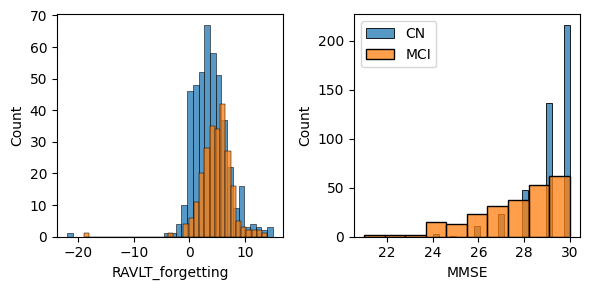

In [14]:
fig, axs = plt.subplots(1, 2, figsize = (6,3))

sns.histplot(df[df["DX"] == "CN"]["RAVLT_forgetting"], label = "CN", ax = axs[0])
sns.histplot(df[df["DX"] == "MCI"]["RAVLT_forgetting"], color = "tab:orange", label = "MCI", ax = axs[0])

sns.histplot(df[df["DX"] == "CN"]["MMSE"], label = "CN", ax = axs[1])
sns.histplot(df[df["DX"] == "MCI"]["MMSE"], color = "tab:orange", label = "MCI", ax = axs[1])

plt.legend()
fig.tight_layout()

In [15]:
df["RAVLT_forgetting"]

0      6.0
1      5.0
2      9.0
3      9.0
4      1.0
      ... 
674    5.0
675    4.0
676    5.0
677    7.0
678    4.0
Name: RAVLT_forgetting, Length: 678, dtype: float64

In [16]:
zscore(df["RAVLT_forgetting"]).sort_values()

326   -8.121789
92    -7.184713
83    -2.499331
592   -2.186972
605   -2.186972
         ...   
314    2.810768
124    3.123127
464    3.123127
133    3.123127
21     3.435486
Name: RAVLT_forgetting, Length: 678, dtype: float64

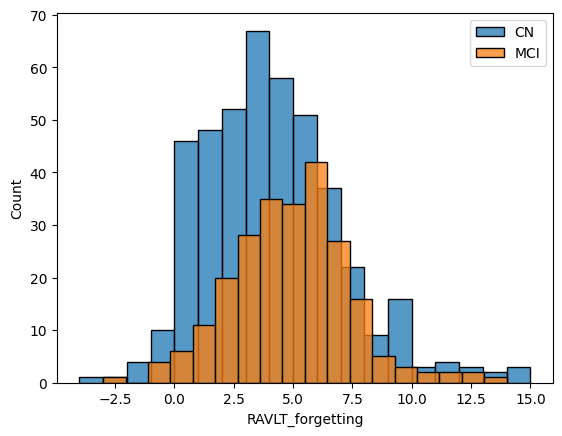

In [17]:
# Remove outlier
df = df[df["RAVLT_forgetting"] > -15].copy()
sns.histplot(df[df["DX"] == "CN"]["RAVLT_forgetting"], label = "CN")
sns.histplot(df[df["DX"] == "MCI"]["RAVLT_forgetting"], color = "tab:orange", label = "MCI")
plt.legend()

In [18]:
# Average left and right values for the ADSIG Mayo mask

adsig_mayo_avg = []

for region in adsig_mayo:
    region_name = region.split("_")[-1]
    left_region = f"CTX_LH_{region_name}"
    right_region = f"CTX_RH_{region_name}"
    df[f"{region_name}_disconn"] = (
        df[f"{left_region}_disconn"] + df[f"{right_region}_disconn"]
    ) / 2
    df[f"{region_name}_THICKNESS"] = (
        df[f"{left_region}_THICKNESS"] + df[f"{right_region}_THICKNESS"]
    ) / 2
    df[f"{region_name}_SUVR_tau"] = (
        df[f"{left_region}_SUVR_tau"] + df[f"{right_region}_SUVR_tau"]
    ) / 2
    df[f"{region_name}_SUVR_amy"] = (
        df[f"{left_region}_SUVR_amy"] + df[f"{right_region}_SUVR_amy"]
    ) / 2
    if not region_name in adsig_mayo_avg:
        adsig_mayo_avg.append(region_name)

/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/leoner/miniconda3/envs/cat_whim/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, 

0.70, 0.00
0.66, 0.00
0.60, 0.00
0.85, 0.00


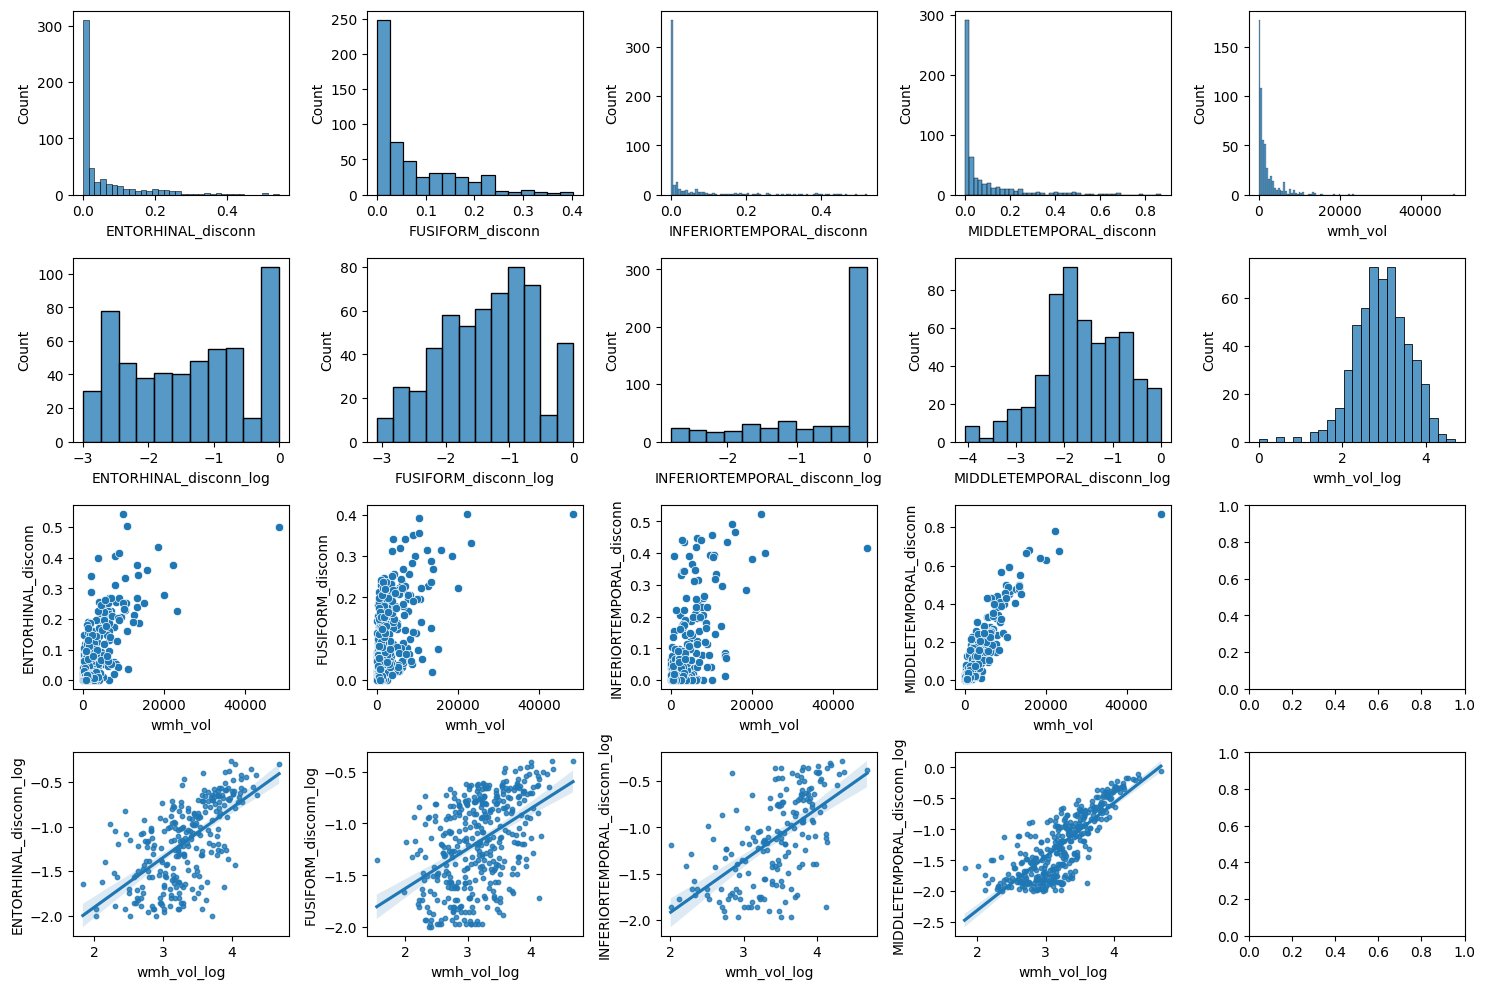

In [19]:
df["wmh_vol_log"] = np.log10(
    df["wmh_vol"], where=(df["wmh_vol"] != 0), out=np.zeros_like(df["wmh_vol"])
)
for region in adsig_mayo_avg:
    disconn = region + "_disconn"
    disconn_log = region + "_disconn_log"
    df[disconn_log] = np.log10(df[disconn], out = np.zeros_like(df[disconn]), where=(df[disconn] != 0))

fig, axs = plt.subplots(4, 5, figsize = (15, 10))
from scipy.stats import spearmanr
for i, region in enumerate(adsig_mayo_avg):

    disconn = region + "_disconn"
    disconn_log = region + "_disconn_log"
    r, p = spearmanr(df[df["session"] == "M00"][disconn], df[df["session"] == "M00"]["wmh_vol_log"])
    print(f"{r:.2f}, {p:.2f}")
    
    sns.histplot(data=df[df["session"] == "M00"], x = disconn, ax = axs[0, i])
    sns.histplot(data=df[df["session"] == "M00"], x = disconn_log, ax = axs[1, i])
    sns.scatterplot(data=df[df["session"] == "M00"], y = disconn, x = "wmh_vol", ax = axs[2, i])
    sns.regplot(data=df[(df["session"] == "M00") & (df[disconn] > 0.01)], y = disconn_log, x = "wmh_vol_log", ax = axs[3, i], scatter_kws = {"s":10}, order=1)

sns.histplot(data=df[df["session"] == "M00"], x = "wmh_vol", ax = axs[0, 4])
sns.histplot(data=df[df["session"] == "M00"], x = "wmh_vol_log", ax = axs[1, 4])
fig.tight_layout()

In [20]:
df.to_csv(PROCESSED_DATA_DIR / "df_cat_whim_final.csv", index=None)

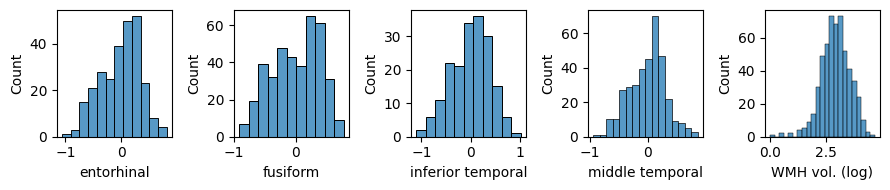

In [21]:
# Regress out the effects of global WMH and plot only in those subj with some segrees of disconnnections
fig, axs = plt.subplots(1, 5, figsize = (9, 2))

for i, region in enumerate(adsig_mayo_avg):
    
    disconn = region + "_disconn"
    disconn_log= region + "_disconn_log"
    disconn_ratio = disconn + "_ratio"
    m = smf.ols(data = df[df[disconn] > 0.01], formula = f"{disconn_log} ~ wmh_vol_log")
    s = m.fit()
    df[disconn_ratio] = s.resid
    sns.histplot(data=df[df["session"] == "M00"], x = disconn_ratio, ax=axs[i])
    axs[i].set_xlabel(region_names[i])
    
sns.histplot(data=df[df["session"] == "M00"], x = "wmh_vol_log", ax = axs[4])
axs[4].set_xlabel("WMH vol. (log)")
fig.tight_layout()

In [22]:
# ggseg has the following names:
dict_conversion_r = {
    "ENTORHINAL": "entorhinal",
    "FUSIFORM": "fusiform",
    "INFERIORTEMPORAL": "inferior temporal",
    "MIDDLETEMPORAL": "middle temporal",
}

dict_res_disconn = {}
dict_res_thickness = {}
dict_res_tau = {}
dict_res_amy = {}

for region in adsig_mayo_avg:

    r_name = dict_conversion_r[region]

    thickness = region + "_THICKNESS"
    disconn = region + "_disconn"
    tau = region + "_SUVR_tau"
    amy = region + "_SUVR_amy"

    dict_res_thickness[r_name] = df[thickness].mean()
    dict_res_disconn[r_name] = df[disconn].mean()
    dict_res_tau[r_name] = df[tau].mean()
    dict_res_amy[r_name] = df[amy].mean()

df_res_thickness = pd.DataFrame(dict_res_thickness, index=["Thickness"]).T.reset_index().rename(columns={"index":"region"})
df_res_disconn = pd.DataFrame(dict_res_disconn, index=["Disconn"]).T.reset_index().rename(columns={"index":"region"})
df_res_tau = pd.DataFrame(dict_res_tau, index=["Tau"]).T.reset_index().rename(columns={"index":"region"})
df_res_amy = pd.DataFrame(dict_res_amy, index=["Amyloid"]).T.reset_index().rename(columns={"index":"region"})

df_res_thickness.to_csv(REPORTS_DIR / "descriptive_results_thickness.csv", index=None)
df_res_disconn.to_csv(REPORTS_DIR / "descriptive_results_disconn.csv", index=None)
df_res_tau.to_csv(REPORTS_DIR / "descriptive_results_tau.csv", index=None)
df_res_amy.to_csv(REPORTS_DIR / "descriptive_results_amy.csv", index=None)

In [23]:
make_demographics_table(df)

AGE mean (SD)


,Variable,All (n = 551)
0,AGE,71.73 ± 7.32
1,PTEDUCAT,16.00 (15.00 - 18.00)
2,MMSE,29.00 (28.00 - 30.00)
3,wmh_vol_log,2.95 (2.52 - 3.36)
4,RAVLT_forgetting,4.00 (2.00 - 6.00)
5,PTGENDER,
6,PTGENDER - Female,302 (54.8%)
7,PTGENDER - Male,249 (45.2%)
8,DX,
9,DX - CN,350 (63.5%)


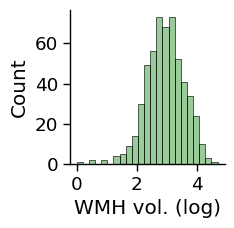

In [24]:
# This is for the methods figure
with sns.plotting_context("paper", font_scale=1.5):
    fig, axs = plt.subplots(1, 1, figsize = (2, 2))
    sns.histplot(data=df[df["session"] == "M00"], x = "wmh_vol_log", ax = axs, color="green", alpha=0.4)
    axs.set_xlabel("WMH vol. (log)")
    sns.despine()
fig.savefig(REPORTS_DIR / "wmh_vol_histogram.svg", dpi = 300, bbox_inches="tight")

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CN vs. MCI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.006e-02 U_stat=3.054e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CN vs. MCI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.217e-01 U_stat=3.240e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

CN vs. MCI: Mann-Whitney-Wilcoxon test two-sided, P_val:1.191e-01 U_stat=3.237e+04
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****

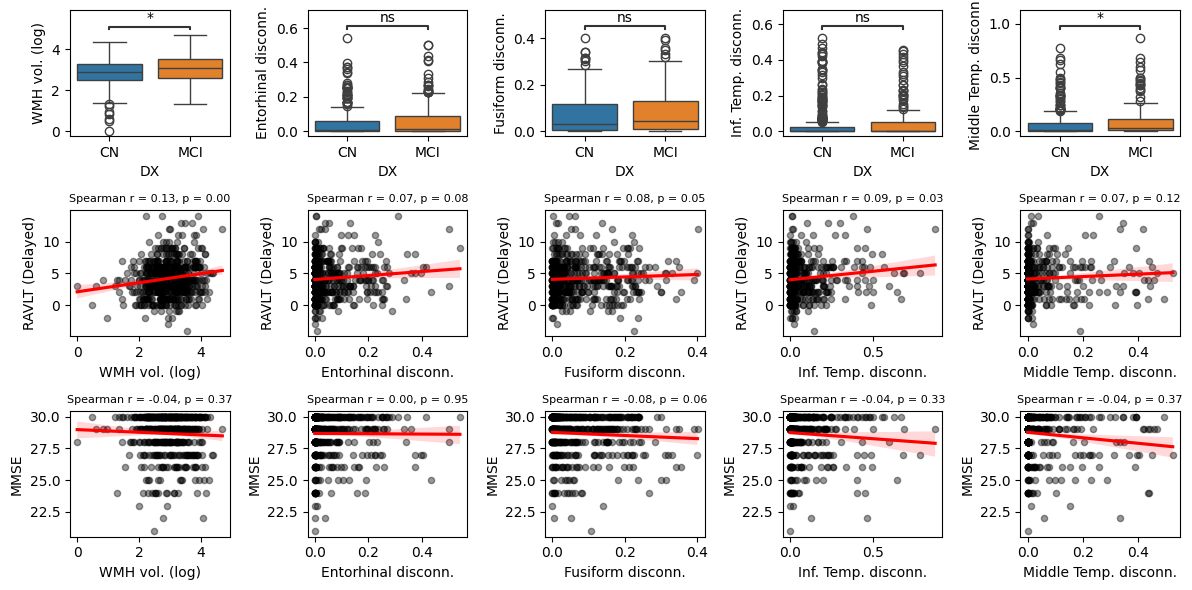

In [25]:
df_m00 = df[df["session"] == "M00"].copy()

fig, axs = plt.subplots(3, 5, figsize=(12, 6))
pairs = [("CN", "MCI")]
plot_boxplot_with_comparison(df_m00, axs[0, 0], "DX", "wmh_vol_log", pairs)
plot_boxplot_with_comparison(df_m00, axs[0, 1], "DX", "ENTORHINAL_disconn", pairs)
plot_boxplot_with_comparison(df_m00, axs[0, 2], "DX", "FUSIFORM_disconn", pairs)
plot_boxplot_with_comparison(df_m00, axs[0, 3], "DX", "INFERIORTEMPORAL_disconn", pairs)
plot_boxplot_with_comparison(df_m00, axs[0, 4], "DX", "MIDDLETEMPORAL_disconn", pairs)

plot_regplot_with_corr(df_m00, "wmh_vol_log", "RAVLT_forgetting", ax=axs[1, 0])
plot_regplot_with_corr(df_m00, "ENTORHINAL_disconn", "RAVLT_forgetting", ax=axs[1, 1])
plot_regplot_with_corr(df_m00, "FUSIFORM_disconn", "RAVLT_forgetting", ax=axs[1, 2])
plot_regplot_with_corr(df_m00, "MIDDLETEMPORAL_disconn", "RAVLT_forgetting", ax=axs[1, 3])
plot_regplot_with_corr(df_m00, "INFERIORTEMPORAL_disconn", "RAVLT_forgetting", ax=axs[1, 4])

plot_regplot_with_corr(df_m00, "wmh_vol_log", "MMSE", ax=axs[2, 0])
plot_regplot_with_corr(df_m00, "ENTORHINAL_disconn", "MMSE", ax=axs[2, 1])
plot_regplot_with_corr(df_m00, "FUSIFORM_disconn", "MMSE", ax=axs[2, 2])
plot_regplot_with_corr(df_m00, "MIDDLETEMPORAL_disconn", "MMSE", ax=axs[2, 3])
plot_regplot_with_corr(df_m00, "INFERIORTEMPORAL_disconn", "MMSE", ax=axs[2, 4])

list_labels = ["WMH vol. (log)", "Entorhinal disconn.", "Fusiform disconn.", "Inf. Temp. disconn.", "Middle Temp. disconn."]

for i,ax in enumerate(axs[0, :]):
    ax.set_ylabel(list_labels[i])

for i,ax in enumerate(axs[1, :]):
    ax.set_ylabel("RAVLT (Delayed)")
    ax.set_xlabel(list_labels[i])

for i,ax in enumerate(axs[2, :]):
    ax.set_xlabel(list_labels[i])

fig.tight_layout()

In [26]:
df["CTX_ETIV"] = df["CTX_ETIV"] / 1000000 # scale down too same order of magnitude as other variables

In [27]:
df_res_adjusted_pretty_wmh, df_res_adjusted_pretty_disconn = calculate_cross_sectional_associations(df, adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", do_zscore=False)
df_res_adjusted_pretty_wmh.to_csv(REPORTS_DIR / "cross_sectional_associations_wmh_thickness_ravlt_zscore.csv", index=None)
df_res_adjusted_pretty_disconn.to_csv(REPORTS_DIR / "cross_sectional_associations_disconn_thickness_ravlt_zscore.csv", index=None)
df_res_adjusted_pretty_wmh

WMH-global                                               \
              region          N            Beta (95% CI)   p-val p-val (FDR)   
0         Entorhinal        551   -0.013 (-0.051, 0.025)     0.5         0.5   
1           Fusiform        551  -0.025 (-0.041, -0.008)  0.0032       0.013   
2  Inferior temporal        551  -0.020 (-0.037, -0.002)   0.027       0.036   
3    Middle temporal        551  -0.020 (-0.037, -0.004)   0.015        0.03   

                  Amyloid                                          Tau  \
            Beta (95% CI)   p-val p-val (FDR)            Beta (95% CI)   
0    0.307 (0.094, 0.520)  0.0048       0.019  -0.319 (-0.379, -0.259)   
1    0.074 (0.015, 0.133)   0.014       0.028  -0.092 (-0.119, -0.065)   
2   0.011 (-0.042, 0.064)    0.68        0.82  -0.063 (-0.090, -0.037)   
3  -0.006 (-0.056, 0.044)    0.82        0.82  -0.074 (-0.101, -0.047)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2  p < 0.0001  p < 0.0001  
3  p < 0.0001  p < 0.0001

In [28]:
df_res_adjusted_pretty_disconn

WMH-focal                                            \
              region         N           Beta (95% CI) p-val p-val (FDR)   
0         Entorhinal       269   0.049 (-0.046, 0.144)  0.31        0.59   
1           Fusiform       392  -0.012 (-0.042, 0.019)  0.44        0.59   
2  Inferior temporal       184   0.030 (-0.015, 0.075)  0.19        0.59   
3    Middle temporal       356   0.003 (-0.036, 0.043)  0.87        0.87   

                  Amyloid                                         Tau  \
            Beta (95% CI)  p-val p-val (FDR)            Beta (95% CI)   
0   0.272 (-0.016, 0.560)  0.064        0.13  -0.330 (-0.429, -0.231)   
1    0.081 (0.012, 0.149)  0.021       0.082  -0.103 (-0.135, -0.071)   
2  -0.018 (-0.102, 0.065)   0.66        0.81  -0.065 (-0.105, -0.025)   
3  -0.007 (-0.066, 0.052)   0.81        0.81  -0.076 (-0.107, -0.045)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2      0.0015      0.0015  
3  p < 0.0001  p < 0.0001

In [29]:
df_res_adjusted_pretty_wmh, df_res_adjusted_pretty_disconn = calculate_cross_sectional_associations(df[df["AMYLOID_STATUS"] == 1], adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", do_zscore=False)
df_res_adjusted_pretty_wmh.to_csv(REPORTS_DIR / "cross_sectional_associations_wmh_thickness_ravlt_amyloid.csv", index=None)
df_res_adjusted_pretty_disconn.to_csv(REPORTS_DIR / "cross_sectional_associations_disconn_thickness_ravlt_amyloid.csv", index=None)
df_res_adjusted_pretty_wmh

WMH-global                                              \
              region          N            Beta (95% CI)  p-val p-val (FDR)   
0         Entorhinal        201  -0.068 (-0.132, -0.003)  0.039       0.039   
1           Fusiform        201  -0.042 (-0.076, -0.009)  0.014       0.028   
2  Inferior temporal        201  -0.037 (-0.070, -0.004)   0.03       0.039   
3    Middle temporal        201  -0.040 (-0.071, -0.009)  0.011       0.028   

                  Amyloid                                        Tau  \
            Beta (95% CI) p-val p-val (FDR)            Beta (95% CI)   
0   0.132 (-0.184, 0.448)  0.41        0.62  -0.230 (-0.306, -0.153)   
1   0.040 (-0.063, 0.143)  0.44        0.62  -0.097 (-0.131, -0.062)   
2  -0.027 (-0.117, 0.062)  0.55        0.62  -0.068 (-0.100, -0.037)   
3  -0.022 (-0.111, 0.067)  0.62        0.62  -0.083 (-0.115, -0.050)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2  p < 0.0001  p < 0.0001  
3  p < 0.0001  p < 0.0001

In [30]:
df_res_adjusted_pretty_disconn

WMH-focal                                            \
              region         N           Beta (95% CI) p-val p-val (FDR)   
0         Entorhinal       115   0.037 (-0.107, 0.181)  0.61        0.77   
1           Fusiform       161   0.008 (-0.049, 0.065)  0.77        0.77   
2  Inferior temporal        78   0.066 (-0.019, 0.151)  0.12         0.5   
3    Middle temporal       142  -0.032 (-0.108, 0.044)   0.4        0.77   

                  Amyloid                                        Tau  \
            Beta (95% CI) p-val p-val (FDR)            Beta (95% CI)   
0   0.086 (-0.327, 0.500)  0.68        0.87  -0.266 (-0.385, -0.147)   
1   0.060 (-0.059, 0.178)  0.32        0.87  -0.106 (-0.147, -0.066)   
2  -0.043 (-0.201, 0.115)  0.59        0.87  -0.054 (-0.107, -0.001)   
3  -0.009 (-0.114, 0.097)  0.87        0.87  -0.089 (-0.126, -0.051)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2       0.044       0.044  
3  p < 0.0001  p < 0.0001

ENTORHINAL
FUSIFORM
INFERIORTEMPORAL
MIDDLETEMPORAL


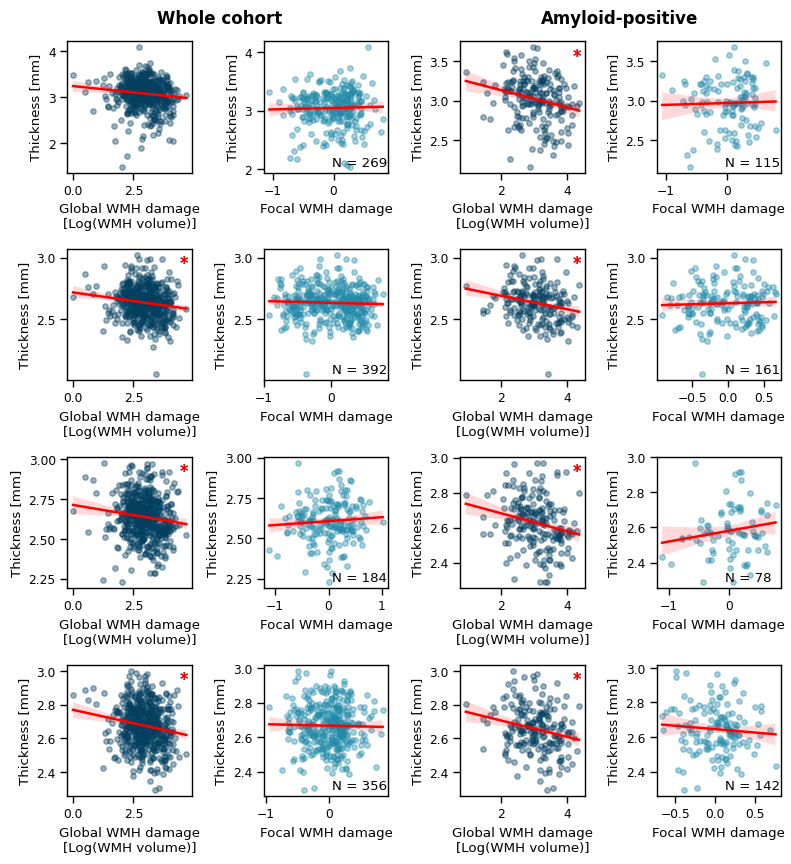

In [49]:
with sns.plotting_context("paper", font_scale=1):

    fig, axs = plt.subplots(4, 4, figsize=(8, 8.5))

    for i, region in enumerate(adsig_mayo_avg):
        disconn = region + "_disconn"
        thickness = region + "_THICKNESS"
        disconn_ratio = region + "_disconn_ratio"
        tau = region + "_SUVR_tau"

        sns.regplot(data=df_m00, x = "wmh_vol_log", y = thickness, scatter_kws = {"s": 15, "color":"#034060", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[i, 0])
        sns.regplot(data=df_m00[df_m00[disconn] > 0.01], x = disconn_ratio, y = thickness, scatter_kws = {"s": 15, "color":"#228BAA", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[i, 1])

        sns.regplot(data=df_m00[df_m00["AMYLOID_STATUS"] == 1], x = "wmh_vol_log", y = thickness, scatter_kws = {"s": 15, "color":"#034060", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[i, 2])
        sns.regplot(data=df_m00[(df_m00[disconn] > 0.01) & (df_m00["AMYLOID_STATUS"] == 1)], x = disconn_ratio, y = thickness, scatter_kws = {"s": 15, "color":"#228BAA", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[i, 3])        

        axs[i, 0].set_ylabel("Thickness [mm]")
        axs[i, 1].set_ylabel("Thickness [mm]")
        axs[i, 2].set_ylabel("Thickness [mm]")
        axs[i, 3].set_ylabel("Thickness [mm]")

        axs[i, 0].set_xlabel("Global WMH damage\n[Log(WMH volume)]")
        axs[i, 1].set_xlabel("Focal WMH damage")
        axs[i, 2].set_xlabel("Global WMH damage\n[Log(WMH volume)]")
        axs[i, 3].set_xlabel("Focal WMH damage")

        axs[i, 1].text(0.55, 0.05, f"N = {df_m00[df_m00[disconn] > 0.01]['PTID'].nunique()}", transform=axs[i, 1].transAxes)
        axs[i, 3].text(0.55, 0.05, f"N = {df_m00[(df_m00[disconn] > 0.01) & (df_m00['AMYLOID_STATUS'] == 1)]['PTID'].nunique()}", transform=axs[i, 3].transAxes)
        
        # Plot asterisk for significance
        axs[1, 0].text(0.9, 0.85, "*", transform=axs[1,0].transAxes, fontsize=12, color = "red")
        axs[2, 0].text(0.9, 0.85, "*", transform=axs[2,0].transAxes, fontsize=12, color = "red")
        axs[3, 0].text(0.9, 0.85, "*", transform=axs[3,0].transAxes, fontsize=12, color = "red")

        axs[0, 2].text(0.9, 0.85, "*", transform=axs[0,2].transAxes, fontsize=12, color = "red")
        axs[1, 2].text(0.9, 0.85, "*", transform=axs[1,2].transAxes, fontsize=12, color = "red")
        axs[2, 2].text(0.9, 0.85, "*", transform=axs[2,2].transAxes, fontsize=12, color = "red")
        axs[3, 2].text(0.9, 0.85, "*", transform=axs[3,2].transAxes, fontsize=12, color = "red")

        print(region)

    fig.text(0.28, 1, "Whole cohort", ha='center', va='center', fontsize=12, weight='bold')
    fig.text(0.78, 1, "Amyloid-positive", ha='center', va='center', fontsize=12, weight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(REPORTS_DIR / "results_cross_sectional.svg", dpi = 500, bbox_inches='tight')

ENTORHINAL
FUSIFORM
INFERIORTEMPORAL
MIDDLETEMPORAL


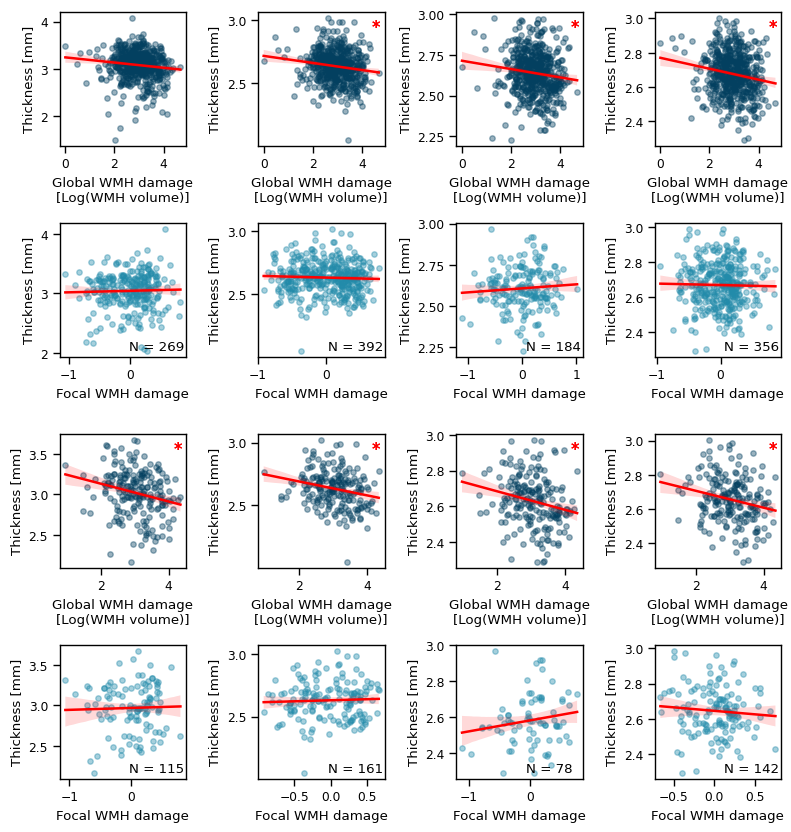

In [52]:
with sns.plotting_context("paper", font_scale=1):

    fig, axs = plt.subplots(4, 4, figsize=(8, 8.5))

    for i, region in enumerate(adsig_mayo_avg):
        disconn = region + "_disconn"
        thickness = region + "_THICKNESS"
        disconn_ratio = region + "_disconn_ratio"
        tau = region + "_SUVR_tau"

        sns.regplot(data=df_m00, x = "wmh_vol_log", y = thickness, scatter_kws = {"s": 15, "color":"#034060", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[0, i])
        sns.regplot(data=df_m00[df_m00[disconn] > 0.01], x = disconn_ratio, y = thickness, scatter_kws = {"s": 15, "color":"#228BAA", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[1, i])

        sns.regplot(data=df_m00[df_m00["AMYLOID_STATUS"] == 1], x = "wmh_vol_log", y = thickness, scatter_kws = {"s": 15, "color":"#034060", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[2, i])
        sns.regplot(data=df_m00[(df_m00[disconn] > 0.01) & (df_m00["AMYLOID_STATUS"] == 1)], x = disconn_ratio, y = thickness, scatter_kws = {"s": 15, "color":"#228BAA", "alpha": 0.4}, line_kws={"color":"red"}, ax=axs[3, i])        

        axs[0, i].set_ylabel("Thickness [mm]")
        axs[1, i].set_ylabel("Thickness [mm]")
        axs[2, i].set_ylabel("Thickness [mm]")
        axs[3, i].set_ylabel("Thickness [mm]")

        axs[0, i].set_xlabel("Global WMH damage\n[Log(WMH volume)]")
        axs[1, i].set_xlabel("Focal WMH damage")
        axs[2, i].set_xlabel("Global WMH damage\n[Log(WMH volume)]")
        axs[3, i].set_xlabel("Focal WMH damage")

        axs[1, i].text(0.55, 0.05, f"N = {df_m00[df_m00[disconn] > 0.01]['PTID'].nunique()}", transform=axs[1, i].transAxes)
        axs[3, i].text(0.55, 0.05, f"N = {df_m00[(df_m00[disconn] > 0.01) & (df_m00['AMYLOID_STATUS'] == 1)]['PTID'].nunique()}", transform=axs[3, i].transAxes)
        
        # Plot asterisk for significance
        axs[0, 1].text(0.9, 0.85, "*", transform=axs[0, 1].transAxes, fontsize=12, color = "red")
        axs[0, 2].text(0.9, 0.85, "*", transform=axs[0, 2].transAxes, fontsize=12, color = "red")
        axs[0, 3].text(0.9, 0.85, "*", transform=axs[0, 3].transAxes, fontsize=12, color = "red")

        axs[2, 0].text(0.9, 0.85, "*", transform=axs[2, 0].transAxes, fontsize=12, color = "red")
        axs[2, 1].text(0.9, 0.85, "*", transform=axs[2, 1].transAxes, fontsize=12, color = "red")
        axs[2, 2].text(0.9, 0.85, "*", transform=axs[2, 2].transAxes, fontsize=12, color = "red")
        axs[2, 3].text(0.9, 0.85, "*", transform=axs[2, 3].transAxes, fontsize=12, color = "red")

        print(region)

    # fig.text(0.28, 1, "Whole cohort", ha='center', va='center', fontsize=12, weight='bold')
    # fig.text(0.78, 1, "Amyloid-positive", ha='center', va='center', fontsize=12, weight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.99])
# plt.savefig(REPORTS_DIR / "results_cross_sectional.svg", dpi = 500, bbox_inches='tight')

# Longitudinal analyses

In [32]:
# # Call the function
df_res_adjusted_pretty_wmh, df_res_adjusted_pretty_disconn = calculate_longitudinal_associations(df, adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", adjusted=True)
df_res_adjusted_pretty_wmh

WMH-global                                      
              region          N           Beta (95% CI) p-value FDR-p
0         Entorhinal        125   0.003 (-0.007, 0.013)    0.58  0.79
1           Fusiform        125   0.003 (-0.002, 0.008)    0.24  0.79
2  Inferior temporal        125   0.001 (-0.004, 0.005)    0.79  0.79
3    Middle temporal        125  -0.001 (-0.004, 0.003)    0.76  0.79

In [33]:
df_res_adjusted_pretty_disconn

WMH-focal                                      
              region         N           Beta (95% CI) p-value FDR-p
0         Entorhinal        52  -0.005 (-0.048, 0.037)    0.81  0.81
1           Fusiform        74   0.003 (-0.009, 0.015)    0.60  0.80
2  Inferior temporal        31  -0.006 (-0.021, 0.008)    0.40  0.80
3    Middle temporal        63  -0.007 (-0.025, 0.011)    0.43  0.80

In [34]:
# # Call the function
df_res_adjusted_pretty_wmh, df_res_adjusted_pretty_disconn = calculate_longitudinal_associations(df[df["AMYLOID_STATUS"] == 1], adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", adjusted=True)
df_res_adjusted_pretty_wmh

WMH-global                                      
              region          N           Beta (95% CI) p-value FDR-p
0         Entorhinal         59   0.003 (-0.020, 0.025)    0.81  0.81
1           Fusiform         59   0.006 (-0.005, 0.017)    0.31  0.81
2  Inferior temporal         59  -0.002 (-0.014, 0.009)    0.70  0.81
3    Middle temporal         59  -0.004 (-0.014, 0.006)    0.41  0.81

In [35]:
df_res_adjusted_pretty_disconn

WMH-focal                                      
              region         N           Beta (95% CI) p-value FDR-p
0         Entorhinal        31  -0.022 (-0.090, 0.046)    0.53  0.60
1           Fusiform        41  -0.006 (-0.028, 0.016)    0.57  0.60
2  Inferior temporal        21  -0.011 (-0.044, 0.022)    0.50  0.60
3    Middle temporal        35  -0.012 (-0.055, 0.032)    0.60  0.60

In [36]:
adjusted=True
roi_list = adsig_mayo_avg
apoe = False
dx_var = "RAVLT_forgetting"
roi_names = region_names

subjs_with_fu = df[df["session"] == "M01"]["PTID"].unique()
df_long = df[df["PTID"].isin(subjs_with_fu)].copy()
df_m00 = df[df["session"] == "M00"].copy()

threshold = np.quantile(df_m00["wmh_vol_log"], 0.66)
print(threshold)

df_m00["WMH_group"] = np.where(df_m00["wmh_vol_log"] > threshold, 1, 0)
df_long = pd.merge(df_m00[["PTID", "WMH_group"]], df_long, on = "PTID")
df_long = df_long[df_long["WMH_group"] == 1].copy()

# df_m00_amy = df_m00[df_m00["AMYLOID_STATUS"] == 1].copy()

# # Step 3: Calculate the highest tertile of WMH volume within amyloid-positive subjects
# wmh_amyloid_positive_threshold = np.quantile(df_m00_amy["wmh_vol"], 0.66)
# df_m00_amy["WMH_group"] = np.where(df_m00_amy["wmh_vol"] > wmh_amyloid_positive_threshold, 1, 0)

# # Step 4: Filter amyloid-positive subjects in the highest WMH tertile
# df_m00_amy_high_wmh = df_m00_amy[df_m00_amy["WMH_group"] == 1]

# # Step 5: Restrict to subjects with follow-up data
# subjs_fu_amy_high_wmh = df_m00_amy_high_wmh[df_m00_amy_high_wmh["PTID"].isin(subjs_with_fu)]["PTID"].unique()

# # Step 6: Extract longitudinal data for the filtered subjects
# df_long = df[df["PTID"].isin(subjs_fu_amy_high_wmh)].copy()


list_beta_disconn = []
list_p_disconn = []
list_disconn_ci_lower = []
list_disconn_ci_upper = []

list_beta_wmh = []
list_p_wmh = []
list_wmh_ci_lower = []
list_wmh_ci_upper = []

list_n_wmh = []
list_n_disconn = []

# df_long["wmh_vol_log"] = zscore_also_longitudinal(df, "wmh_vol_log")
# df_long["RAVLT_forgetting"] = zscore_also_longitudinal(df, "RAVLT_forgetting")

for region in roi_list: 

    disconn = region + "_disconn"
    disconn_ratio = region + "_disconn_ratio"
    thickness = region + "_THICKNESS"
    amy = region + "_SUVR_amy"
    tau = region + "_SUVR_tau"

    # df_long[disconn_ratio] = zscore_also_longitudinal(df, disconn_ratio)
    # df_long[thickness] = zscore_also_longitudinal(df, thickness)
    # df_long[amy] = zscore_also_longitudinal(df, amy)
    # df_long[tau] = zscore_also_longitudinal(df, tau)

    df_m00 = df[df["session"] == "M00"].copy()
    df_m01 = df[df["session"] == "M01"].copy()

    # df_m00_no_disconn = df_m00[df_m00[disconn] < 0.01]["PTID"] # subjects with no disconnections at the first session
    # df_m01_no_disconn = df_m01[df_m01[disconn] < 0.01]["PTID"] # subjects with no disconnections at the second session
    # df_long_disconn = df_long[~df_long["PTID"].isin(df_m00_no_disconn)].copy()
    # df_long_disconn = df_long_disconn[~df_long_disconn["PTID"].isin(df_m01_no_disconn)].copy()
    
    # df_m00["disconn_group"] = np.where(df_m00[disconn] > np.quantile(df_m00[disconn], 0.66), 1, 0)
    # df_long_disconn = pd.merge(df_m00[["PTID", "disconn_group"]], df_long, on = "PTID").dropna(subset=disconn_ratio)
    
    if not adjusted:
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00"

    elif adjusted and not apoe:
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
    
    elif adjusted and apoe:
        df_long = df_long[~df_long["APOE4"].isnull()].copy()
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4" 

    df_long = df_long[df_long["AMYLOID_STATUS"] == 1]
    # Fit the models
    lr_wmh = smf.mixedlm(data=df_long, formula=formula_wmh, groups=df_long["PTID"])
    res_wmh = lr_wmh.fit()

    # lr_disconn = smf.mixedlm(data=df_long_disconn, formula=formula_disconn, groups=df_long_disconn["PTID"])
    # res_disconn = lr_disconn.fit()
    
    # Extract parameter estimates and p-values
    # list_p_disconn.append(res_disconn.pvalues[disconn_ratio])
    # list_beta_disconn.append(res_disconn.params[disconn_ratio])

    list_p_wmh.append(res_wmh.pvalues["wmh_vol_log:Years_m00"])
    list_beta_wmh.append(res_wmh.params["wmh_vol_log:Years_m00"])

    # Extract 95% confidence intervals for each parameter
    # disconn_ci = res_disconn.conf_int().loc[disconn_ratio]
    wmh_ci = res_wmh.conf_int().loc["wmh_vol_log:Years_m00"]

    # Append confidence intervals to the lists
    # list_disconn_ci_lower.append(disconn_ci[0])
    # list_disconn_ci_upper.append(disconn_ci[1])

    list_wmh_ci_lower.append(wmh_ci[0])
    list_wmh_ci_upper.append(wmh_ci[1])

    list_n_wmh.append(df_long["PTID"].nunique())
    # list_n_disconn.append(df_m00_disconn["PTID"].nunique())

    # Convert p-values to arrays and apply FDR correction
    arr_p_disconn = np.array(list_p_disconn)
    arr_p_wmh = np.array(list_p_wmh)

    arr_p_disconn_fdr = false_discovery_control(arr_p_disconn)
    arr_p_wmh_fdr = false_discovery_control(arr_p_wmh)

df_res_pretty = pd.DataFrame({
    "Region": [reg.capitalize()for reg in roi_names],
    "WMH-global_N": list_n_wmh,
    "WMH-global_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_wmh, list_wmh_ci_lower, list_wmh_ci_upper)],
    "WMH-global_p_val": arr_p_wmh,
    "WMH-global_p_val_fdr": arr_p_wmh_fdr,
    # "WMH-focal_N": list_n_disconn,
    # "WMH-focal_beta_disconn": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_disconn, list_disconn_ci_lower, list_disconn_ci_upper)],
    # "WMH-focal_p_val": arr_p_disconn,
    # "WMH-focal_p_val_fdr": arr_p_disconn_fdr,
})

df_res_pretty.columns = pd.MultiIndex.from_tuples([
    ("", "region"),
    ("WMH-global", "N"),
    ("WMH-global", "beta disconn (95% CI)"),
    ("WMH-global", "p-val"),
    ("WMH-global", "p-val (FDR)"),
    # ("WMH-focal", "N"),
    # ("WMH-focal", "beta disconn (95% CI)"),
    # ("WMH-focal", "p-val"),
    # ("WMH-focal", "p-val (FDR)"),
])
df_res_pretty


3.216429830876251


WMH-global                                               
              region          N    beta disconn (95% CI)     p-val p-val (FDR)
0         Entorhinal         21   -0.003 (-0.081, 0.074)  0.936918    0.936918
1           Fusiform         21   -0.009 (-0.041, 0.023)  0.596229    0.794971
2  Inferior temporal         21  -0.037 (-0.072, -0.001)  0.041590    0.144872
3    Middle temporal         21   -0.028 (-0.060, 0.003)  0.072436    0.144872

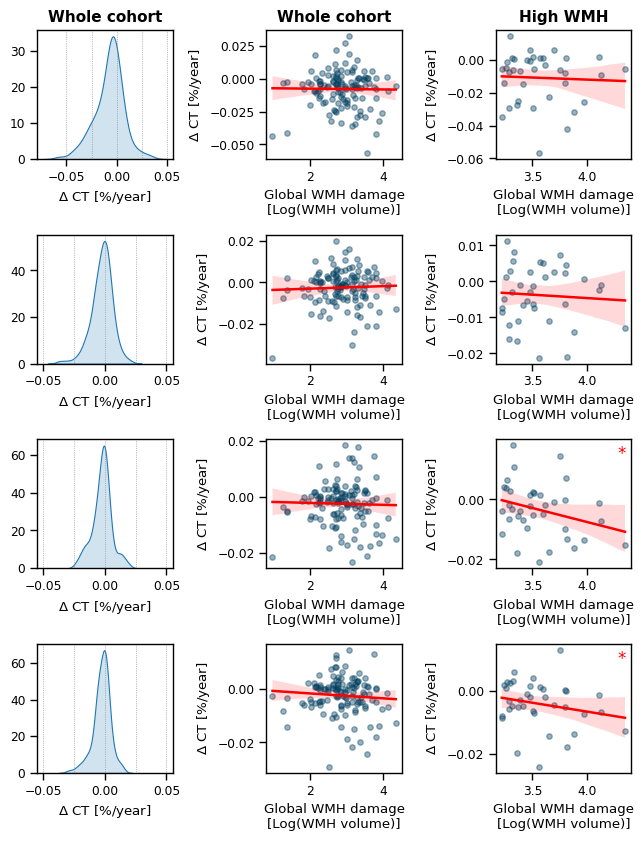

In [37]:
subjs_with_fu = df[df["session"] == "M01"]["PTID"].unique()  # Filter subjects with follow-up (M01)
df_long = df[df["PTID"].isin(subjs_with_fu)].copy()  # Filter for these subjects

with sns.plotting_context("paper", font_scale=1):

    fig, axs = plt.subplots(4, 3, figsize=(6.5, 8.5))

    for i, region in enumerate(adsig_mayo_avg):

        # Define region-specific columns
        thickness = region + "_THICKNESS"
        thickness_delta = thickness + "_delta_annualized"
        disconn = region + "_disconn"
        disconn_ratio = region + "_disconn_ratio"
        tau = region + "_SUVR_tau"

        # Step 1: Pivot the data to separate M00 and M01 sessions
        df_pivot = df_long.pivot_table(
            index="PTID",        # Unique participant identifier
            columns="session",   # Separate M00 and M01 into columns
            values=["Years_m00", "wmh_vol_log", thickness, disconn, disconn_ratio]  # Relevant columns
        )
        # Flatten the multi-level column index for easier access
        df_pivot.columns = ['_'.join(col).strip() for col in df_pivot.columns]

        # Step 2: Calculate the annualized rate of change for cortical thickness
        df_pivot[f"{thickness}_delta_annualized"] = (
            (df_pivot[f"{thickness}_M01"] - df_pivot[f"{thickness}_M00"]) /
            (df_pivot[f"{thickness}_M00"] * df_pivot["Years_m00_M01"])
        )

        sns.kdeplot(
            data=df_pivot,
            x=f"{thickness}_delta_annualized",  # Annualized cortical thickness change
            ax=axs[i, 0],
            fill=True,
            alpha=0.2,
        )
        axs[i, 1].set_ylabel(r"$\Delta$ CT [%/year]")
        axs[i, 1].set_xlabel("Global WMH damage\n[Log(WMH volume)]")

        # Define the range for vertical lines
        start_value = -0.05  # Starting x-coordinate
        end_value = 0.05    # Ending x-coordinate

        # Calculate equally spaced positions for 5 lines
        num_lines = 5
        line_positions = np.linspace(start_value, end_value, num_lines)

        # Add vertical dotted lines
        for x in line_positions:
            axs[i, 0].axvline(x, color="grey", linestyle="dotted", linewidth=0.5)

        axs[i, 0].set_xlabel(r"$\Delta$ CT [%/year]")
        axs[i, 0].set_ylabel("")

        sns.regplot(
            data=df_pivot,
            x="wmh_vol_log_M00",  # Global WMH volume at M00
            y=f"{thickness}_delta_annualized",  # Annualized cortical thickness change
            scatter_kws={"s": 15, "color": "#034060", "alpha": 0.4},  # Dark blue
            line_kws={"color": "red"},  # Regression line in red
            ax=axs[i, 1]
        )
        axs[i, 1].set_ylabel(r"$\Delta$ CT [%/year]")
        axs[i, 1].set_xlabel("Global WMH damage\n[Log(WMH volume)]")

        sns.regplot(
            data=df_pivot[df_pivot["wmh_vol_log_M00"] > threshold],
            x="wmh_vol_log_M00",  # Global WMH volume at M00
            y=f"{thickness}_delta_annualized",  # Annualized cortical thickness change
            scatter_kws={"s": 15, "color": "#034060", "alpha": 0.4},  # Dark blue
            line_kws={"color": "red"},  # Regression line in red
            ax=axs[i, 2]
        )
        axs[i, 2].set_ylabel(r"$\Delta$ CT [%/year]")
        axs[i, 2].set_xlabel("Global WMH damage\n[Log(WMH volume)]")
        if i == 0:
            axs[i, 0].set_title(f"Whole cohort", weight="bold", fontsize=11)
            axs[i, 1].set_title(f"Whole cohort", weight="bold", fontsize=11)
            axs[i, 2].set_title(f"High WMH", weight="bold", fontsize=11)
            

    axs[2, 2].text(0.9, 0.85, "*", transform=axs[2, 2].transAxes, fontsize=12, color = "red")
    axs[3, 2].text(0.9, 0.85, "*", transform=axs[3, 2].transAxes, fontsize=12, color = "red")
    
    # Adjust layout for better spacing between subplots
    fig.tight_layout()
    plt.savefig(REPORTS_DIR / "longitudinal_results.svg", dpi=500)


In [38]:
adjusted=True
roi_list = adsig_mayo_avg
apoe = False
dx_var = "RAVLT_forgetting"
roi_names = region_names

subjs_with_fu = df[df["session"] == "M01"]["PTID"].unique()
df_long = df[df["PTID"].isin(subjs_with_fu)].copy()
df_m00 = df[df["session"] == "M00"].copy()

threshold = np.quantile(df_m00["wmh_vol_log"], 0.66)
print(threshold)

df_m00["WMH_group"] = np.where(df_m00["wmh_vol_log"] > threshold, 1, 0)
df_long = pd.merge(df_m00[["PTID", "WMH_group"]], df_long, on = "PTID")
df_long = df_long[df_long["WMH_group"] == 1].copy()

# df_m00_amy = df_m00[df_m00["AMYLOID_STATUS"] == 1].copy()

# # Step 3: Calculate the highest tertile of WMH volume within amyloid-positive subjects
# wmh_amyloid_positive_threshold = np.quantile(df_m00_amy["wmh_vol"], 0.66)
# df_m00_amy["WMH_group"] = np.where(df_m00_amy["wmh_vol"] > wmh_amyloid_positive_threshold, 1, 0)

# # Step 4: Filter amyloid-positive subjects in the highest WMH tertile
# df_m00_amy_high_wmh = df_m00_amy[df_m00_amy["WMH_group"] == 1]

# # Step 5: Restrict to subjects with follow-up data
# subjs_fu_amy_high_wmh = df_m00_amy_high_wmh[df_m00_amy_high_wmh["PTID"].isin(subjs_with_fu)]["PTID"].unique()

# # Step 6: Extract longitudinal data for the filtered subjects
# df_long = df[df["PTID"].isin(subjs_fu_amy_high_wmh)].copy()


list_beta_disconn = []
list_p_disconn = []
list_disconn_ci_lower = []
list_disconn_ci_upper = []

list_beta_wmh = []
list_p_wmh = []
list_wmh_ci_lower = []
list_wmh_ci_upper = []

list_n_wmh = []
list_n_disconn = []

# df_long["wmh_vol_log"] = zscore_also_longitudinal(df, "wmh_vol_log")
# df_long["RAVLT_forgetting"] = zscore_also_longitudinal(df, "RAVLT_forgetting")

for region in roi_list: 

    disconn = region + "_disconn"
    disconn_ratio = region + "_disconn_ratio"
    thickness = region + "_THICKNESS"
    amy = region + "_SUVR_amy"
    tau = region + "_SUVR_tau"

    # df_long[disconn_ratio] = zscore_also_longitudinal(df, disconn_ratio)
    # df_long[thickness] = zscore_also_longitudinal(df, thickness)
    # df_long[amy] = zscore_also_longitudinal(df, amy)
    # df_long[tau] = zscore_also_longitudinal(df, tau)

    df_m00 = df[df["session"] == "M00"].copy()
    df_m01 = df[df["session"] == "M01"].copy()

    # df_m00_no_disconn = df_m00[df_m00[disconn] < 0.01]["PTID"] # subjects with no disconnections at the first session
    # df_m01_no_disconn = df_m01[df_m01[disconn] < 0.01]["PTID"] # subjects with no disconnections at the second session
    # df_long_disconn = df_long[~df_long["PTID"].isin(df_m00_no_disconn)].copy()
    # df_long_disconn = df_long_disconn[~df_long_disconn["PTID"].isin(df_m01_no_disconn)].copy()
    
    # df_m00["disconn_group"] = np.where(df_m00[disconn] > np.quantile(df_m00[disconn], 0.66), 1, 0)
    # df_long_disconn = pd.merge(df_m00[["PTID", "disconn_group"]], df_long, on = "PTID").dropna(subset=disconn_ratio)
    
    if not adjusted:
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00"

    elif adjusted and not apoe:
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy"
    
    elif adjusted and apoe:
        df_long = df_long[~df_long["APOE4"].isnull()].copy()
        formula_disconn = f"{thickness} ~ {disconn_ratio}*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4"
        formula_wmh = f"{thickness} ~ wmh_vol_log*Years_m00 + {amy} + {tau} + AGE + PTGENDER + C(HMHYPERT) + {dx_var} + PTEDUCAT + CTX_ETIV + TRACER_amy + APOE4" 

    
    # Fit the models
    lr_wmh = smf.mixedlm(data=df_long, formula=formula_wmh, groups=df_long["PTID"])
    res_wmh = lr_wmh.fit()

    # lr_disconn = smf.mixedlm(data=df_long_disconn, formula=formula_disconn, groups=df_long_disconn["PTID"])
    # res_disconn = lr_disconn.fit()
    
    # Extract parameter estimates and p-values
    # list_p_disconn.append(res_disconn.pvalues[disconn_ratio])
    # list_beta_disconn.append(res_disconn.params[disconn_ratio])

    list_p_wmh.append(res_wmh.pvalues["wmh_vol_log:Years_m00"])
    list_beta_wmh.append(res_wmh.params["wmh_vol_log:Years_m00"])

    # Extract 95% confidence intervals for each parameter
    # disconn_ci = res_disconn.conf_int().loc[disconn_ratio]
    wmh_ci = res_wmh.conf_int().loc["wmh_vol_log:Years_m00"]

    # Append confidence intervals to the lists
    # list_disconn_ci_lower.append(disconn_ci[0])
    # list_disconn_ci_upper.append(disconn_ci[1])

    list_wmh_ci_lower.append(wmh_ci[0])
    list_wmh_ci_upper.append(wmh_ci[1])

    list_n_wmh.append(df_long["PTID"].nunique())
    # list_n_disconn.append(df_m00_disconn["PTID"].nunique())

    # Convert p-values to arrays and apply FDR correction
    arr_p_disconn = np.array(list_p_disconn)
    arr_p_wmh = np.array(list_p_wmh)

    arr_p_disconn_fdr = false_discovery_control(arr_p_disconn)
    arr_p_wmh_fdr = false_discovery_control(arr_p_wmh)

df_res_pretty = pd.DataFrame({
    "Region": [reg.capitalize()for reg in roi_names],
    "WMH-global_N": list_n_wmh,
    "WMH-global_beta_wmh": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_wmh, list_wmh_ci_lower, list_wmh_ci_upper)],
    "WMH-global_p_val": arr_p_wmh,
    "WMH-global_p_val_fdr": arr_p_wmh_fdr,
    # "WMH-focal_N": list_n_disconn,
    # "WMH-focal_beta_disconn": [f"{b:.3f} ({ci_lower:.3f}, {ci_upper:.3f})" for b, ci_lower, ci_upper in zip(list_beta_disconn, list_disconn_ci_lower, list_disconn_ci_upper)],
    # "WMH-focal_p_val": arr_p_disconn,
    # "WMH-focal_p_val_fdr": arr_p_disconn_fdr,
})

df_res_pretty.columns = pd.MultiIndex.from_tuples([
    ("", "region"),
    ("WMH-global", "N"),
    ("WMH-global", "beta disconn (95% CI)"),
    ("WMH-global", "p-val"),
    ("WMH-global", "p-val (FDR)"),
    # ("WMH-focal", "N"),
    # ("WMH-focal", "beta disconn (95% CI)"),
    # ("WMH-focal", "p-val"),
    # ("WMH-focal", "p-val (FDR)"),
])
df_res_pretty


3.216429830876251


WMH-global                                               
              region          N    beta disconn (95% CI)     p-val p-val (FDR)
0         Entorhinal         37   -0.017 (-0.067, 0.034)  0.515696    0.515696
1           Fusiform         37   -0.012 (-0.033, 0.009)  0.258562    0.344750
2  Inferior temporal         37  -0.028 (-0.047, -0.008)  0.005203    0.020812
3    Middle temporal         37  -0.020 (-0.037, -0.004)  0.015430    0.030861

# Amyloid-positive

In [39]:
make_demographics_table(df[df["AMYLOID_STATUS"] == 1])

AGE mean (SD)
wmh_vol_log mean (SD)


,Variable,All (n = 201)
0,AGE,73.31 ± 7.04
1,PTEDUCAT,16.00 (15.00 - 18.00)
2,MMSE,29.00 (27.00 - 30.00)
3,wmh_vol_log,3.03 ± 0.61
4,RAVLT_forgetting,5.00 (3.00 - 6.00)
5,PTGENDER,
6,PTGENDER - Female,115 (57.2%)
7,PTGENDER - Male,86 (42.8%)
8,DX,
9,DX - CN,102 (50.7%)


In [40]:
df_res_adjusted_pretty_wmh, df_res_adjusted_pretty_disconn = calculate_cross_sectional_associations(df[df["AMYLOID_STATUS"] == 1], adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", do_zscore=True)
df_res_adjusted_pretty_wmh

WMH-global                                              \
              region          N            Beta (95% CI)  p-val p-val (FDR)   
0         Entorhinal        201  -0.144 (-0.281, -0.007)  0.039       0.039   
1           Fusiform        201  -0.177 (-0.318, -0.036)  0.014       0.028   
2  Inferior temporal        201  -0.159 (-0.302, -0.016)   0.03       0.039   
3    Middle temporal        201  -0.181 (-0.320, -0.042)  0.011       0.028   

                  Amyloid                                        Tau  \
            Beta (95% CI) p-val p-val (FDR)            Beta (95% CI)   
0   0.055 (-0.077, 0.186)  0.41        0.62  -0.397 (-0.530, -0.264)   
1   0.056 (-0.088, 0.201)  0.44        0.62  -0.400 (-0.543, -0.258)   
2  -0.044 (-0.187, 0.099)  0.55        0.62  -0.310 (-0.452, -0.167)   
3  -0.036 (-0.177, 0.106)  0.62        0.62  -0.363 (-0.505, -0.221)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2  p < 0.0001  p < 0.0001  
3  p < 0.0001  p < 0.0001

In [41]:
for i in range (4):
    print(float(df_res_adjusted_pretty_wmh["WMH-global"]["Beta (95% CI)"][i][:6]) / float(df_res_adjusted_pretty_wmh["Tau"]["Beta (95% CI)"][i][:6]))

0.36272040302267
0.44249999999999995
0.5129032258064516
0.4986225895316804


In [42]:
df_res_adjusted_pretty_disconn

WMH-focal                                            \
              region         N           Beta (95% CI) p-val p-val (FDR)   
0         Entorhinal       115   0.037 (-0.107, 0.181)  0.61        0.77   
1           Fusiform       161   0.008 (-0.049, 0.065)  0.77        0.77   
2  Inferior temporal        78   0.066 (-0.019, 0.151)  0.12         0.5   
3    Middle temporal       142  -0.032 (-0.108, 0.044)   0.4        0.77   

                  Amyloid                                        Tau  \
            Beta (95% CI) p-val p-val (FDR)            Beta (95% CI)   
0   0.086 (-0.327, 0.500)  0.68        0.87  -0.266 (-0.385, -0.147)   
1   0.060 (-0.059, 0.178)  0.32        0.87  -0.106 (-0.147, -0.066)   
2  -0.043 (-0.201, 0.115)  0.59        0.87  -0.054 (-0.107, -0.001)   
3  -0.009 (-0.114, 0.097)  0.87        0.87  -0.089 (-0.126, -0.051)   

                           
        p-val p-val (FDR)  
0  p < 0.0001  p < 0.0001  
1  p < 0.0001  p < 0.0001  
2       0.044       0.044  
3  p < 0.0001  p < 0.0001

In [43]:
df_res_adjusted_pretty = calculate_longitudinal_associations(df[df["AMYLOID_STATUS"] == 1], adsig_mayo_avg, region_names, dx_var = "RAVLT_forgetting", adjusted=True)
df_res_adjusted_pretty

(                     WMH-global                                      
               region          N           Beta (95% CI) p-value FDR-p
 0         Entorhinal         59   0.003 (-0.020, 0.025)    0.81  0.81
 1           Fusiform         59   0.006 (-0.005, 0.017)    0.31  0.81
 2  Inferior temporal         59  -0.002 (-0.014, 0.009)    0.70  0.81
 3    Middle temporal         59  -0.004 (-0.014, 0.006)    0.41  0.81,
                      WMH-focal                                      
               region         N           Beta (95% CI) p-value FDR-p
 0         Entorhinal        31  -0.022 (-0.090, 0.046)    0.53  0.60
 1           Fusiform        41  -0.006 (-0.028, 0.016)    0.57  0.60
 2  Inferior temporal        21  -0.011 (-0.044, 0.022)    0.50  0.60
 3    Middle temporal        35  -0.012 (-0.055, 0.032)    0.60  0.60)

## Brain illustration for Figure 1

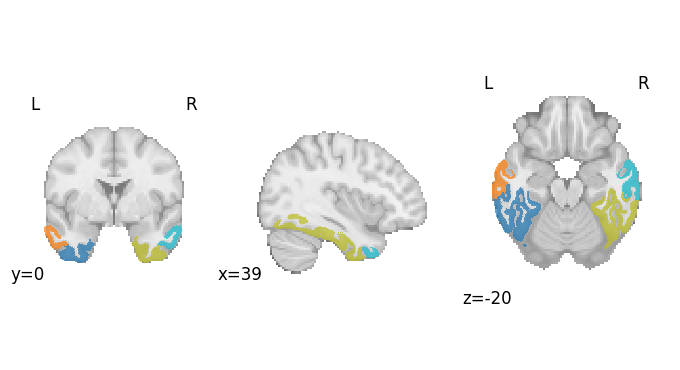

In [44]:
import abagen
import nibabel as nib
import nilearn.plotting as niplot

atlas = abagen.fetch_desikan_killiany()
atlas_nifti = nib.load(atlas["image"])
dk_arr = atlas_nifti.get_fdata()
ids = np.array([5, 6, 8, 14, 46, 47, 49, 55])
# Use np.isin to create a boolean mask for elements in dk_arr that are in ids_array
mask = np.isin(dk_arr, ids)

# Set all values in dk_arr that are not in the mask to 0
dk_arr[~mask] = 0
new_dk = nib.Nifti1Image(dk_arr, atlas_nifti.affine, atlas_nifti.header)

niplot.plot_roi(new_dk, draw_cross=False, cmap="tab10", cut_coords = [39, 0, -20])
plt.savefig(REPORTS_DIR / "brain_dk_atlas.png", dpi = 500)

